# Routh Array

In [1]:
import os.path,  importlib.util

if importlib.util.find_spec('tbcontrol') is None:
    os.system(f'python -m pip install tbcontrol')

from tbcontrol.symbolic import routh

import numpy as np
import sympy 
from sympy import fraction, roots, re, N 
sympy.init_printing()
print('sympy version '+sympy.__version__)

s = sympy.Symbol('s')
a_0, a_1, a_2, a_3, a_4 = sympy.symbols('a_0:5')
K_c = sympy.Symbol('K_c')

if not os.path.isdir("./figs/"):
    os.mkdir("./figs")


sympy version 1.13.3


In [2]:
help(routh)

Help on function routh in module tbcontrol.symbolic:

routh(p)
    Construct the Routh-Hurwitz array given a polynomial in s

    Input: p - a sympy.Poly object
    Output: The Routh-Hurwitz array as a sympy.Matrix object



In [3]:
def display_roots(p):
    rr = p.nroots()
    for root in rr:
        r, i = root.as_real_imag()
        if abs(i) > 1e-5:
            print('%8.3f %8.3fi' % (r,i))
        else:
            print('%8.3f' % (r))

## Example 8-8

In [4]:
# 8-8
p = s**6 + 7*s**5 + 13*s**4 + 8*s**3 + 5*s**2 + 10*s + 16
p = sympy.Poly(p, s)
p

In [5]:
display_roots(p)

  -4.434
  -2.000
  -0.907   -0.933i
  -0.907    0.933i
   0.625   -0.822i
   0.625    0.822i


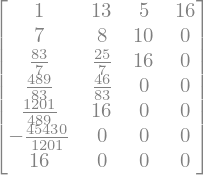

In [6]:
routh(p)

## Example 8-11

In [7]:
p = s**3 + 4*s**2 + 8*s + 4
p = sympy.Poly(p, s)
p

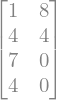

In [8]:
RA = routh(p)
RA

In [9]:
msgs = 'Stable' if min(RA[:, 0]) > 0 else 'Unstable'
print(msgs)

Stable


In [10]:
display_roots(p)

  -0.704
  -1.648   -1.721i
  -1.648    1.721i


## Now check if poles satisfy $Re[s] \leq h$

In [11]:
h = -0.71
pa = p.subs(s,s+h)
pa = sympy.Poly(pa, s)
pa

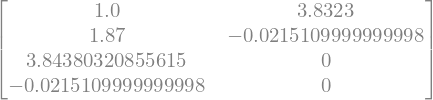

In [12]:
RAa = routh(pa)
RAa

In [13]:
msgs = 'are' if min(RAa[:, 0]) > 0 else 'are not'
print('Poles '+msgs+' left of s = '+str(h))

Poles are not left of s = -0.71


## Example 8-12

In [14]:
Gnum = s-1
Gden = s**3 + 0.5*s**2 + 0.5*s + 1 
p = Gden + K_c*Gnum
p = sympy.Poly(p, s)
p

In [15]:
np.roots([1, 0.5, 0.5, 1])

array([-1.  +0.j        ,  0.25+0.96824584j,  0.25-0.96824584j])

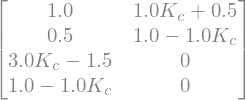

In [16]:
RA = routh(sympy.Poly(p, s))
RA

In [17]:
rr = sympy.solve([e > 0 for e in RA[:, 0]], K_c)
rr

In [18]:
for k_c in np.arange(0,rr.args[1].args[1]*1.1,.1):
    r = roots(p.subs(K_c,k_c))
    N = len(r)
    real_part = [re(e) for e in list(r)[0:N]]
    msgs = 'Stable'
    if max(real_part) >= 0:
        msgs = 'Unstable'        
    print(f'For K_c = {k_c:5.1f} system is '+msgs)

For K_c =   0.0 system is Unstable
For K_c =   0.1 system is Unstable
For K_c =   0.2 system is Unstable
For K_c =   0.3 system is Unstable
For K_c =   0.4 system is Unstable
For K_c =   0.5 system is Unstable
For K_c =   0.6 system is Stable
For K_c =   0.7 system is Stable
For K_c =   0.8 system is Stable
For K_c =   0.9 system is Stable
For K_c =   1.0 system is Unstable


In [19]:
import matplotlib.pyplot as plt
from matplotlib.pyplot import figure, savefig
%matplotlib inline

def nicegrid():
    plt.grid(True, which='major', color='#666666', linestyle='-')
    plt.grid(True, which='minor', color='#999999', linestyle='-', alpha=0.2)
    plt.minorticks_on()

In [20]:
RR = np.linspace(0,1,200)
R = np.zeros((len(RR),3),dtype=complex)
for ii,k_c in enumerate(RR):
    r = roots(p.subs(K_c,k_c))
    R[ii,:] = [e for e in list(r)[0:len(r)]]

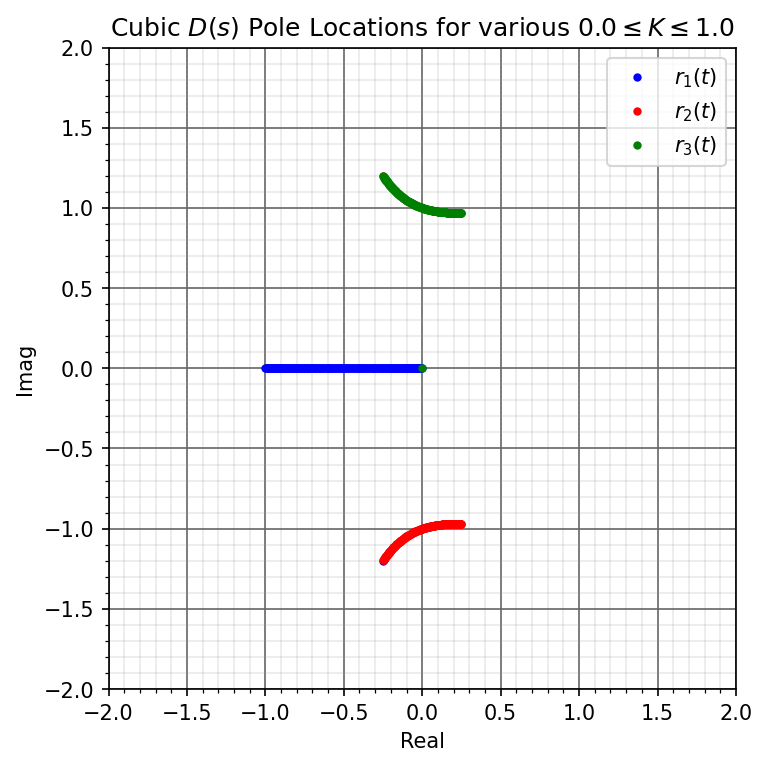

In [21]:
fig = plt.figure(figsize=(5, 5),dpi=150,constrained_layout = True)
plt.plot(np.real(R[:,0]),np.imag(R[:,0]),'b.',linewidth=4,label='$r_1(t)$')
plt.plot(np.real(R[:,1]),np.imag(R[:,1]),'r.',linewidth=4,label='$r_2(t)$')
plt.plot(np.real(R[:,2]),np.imag(R[:,2]),'g.',linewidth=4,label='$r_3(t)$')

nicegrid()
plt.legend()
plt.xlim(-2,2)
plt.ylim(-2,2)
plt.xlabel('Real')
plt.ylabel('Imag')
plt.title('Cubic $D(s)$ Pole Locations for various ${:3.1f}\leq K \leq {:3.1f}$'.format(min(RR),max(RR)))
savefig("./figs/RA_8_12.pdf", dpi=600)
plt.show()

In [22]:
rr

In [23]:
f = sympy.lambdify(K_c, RA)
f(1)

array([[1. , 1.5],
       [0.5, 0. ],
       [1.5, 0. ],
       [0. , 0. ]])

In [24]:
f(-2)

array([[ 1. , -1.5],
       [ 0.5,  3. ],
       [-7.5,  0. ],
       [ 3. ,  0. ]])

In [25]:
def count_sign_changes(A, tol=1e-9):
    col = A[:, 0]
    col = col[np.abs(col) > tol]
    
    signs = np.sign(col)
    return np.sum(signs[:-1] * signs[1:] < 0)

In [26]:
count_sign_changes(f(1))

0

In [27]:
count_sign_changes(f(-2))

2